In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Earthquake_GNN"

os.makedirs(project_path, exist_ok=True)

### Step 1: Install `kagglehub` and Download the Dataset

We will use `kagglehub` to directly download the dataset from Kaggle. This simplifies the process by handling authentication implicitly if you're using a Colab environment or have Kaggle credentials set up elsewhere. If you encounter authentication issues, you might need to revert to the previous method or ensure your Colab environment is linked to a Google account associated with Kaggle.

The dataset identifier for 'The Ultimate Earthquake Dataset From 1990-2023' is `alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023`.

In [ ]:
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Dataset identifier
dataset_id = 'alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023'

# Download the dataset
# kagglehub typically downloads to a cached directory and returns its path
print(f"Downloading dataset: {dataset_id}")
download_path = kagglehub.dataset_download(dataset_id)

print(f"Dataset downloaded to: {download_path}")

# List files in the downloaded directory to identify the CSV
downloaded_files = os.listdir(download_path)
print("Files in downloaded directory:", downloaded_files)

# Corrected: The main data file is 'Eartquakes-1990-2023.csv'
# Adjust this if the filename is different based on the `downloaded_files` output
csv_file_name = 'Eartquakes-1990-2023.csv'
csv_file_path = os.path.join(download_path, csv_file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("\nFirst 5 rows of the DataFrame:")
display(df.head())

100%|██████████| 116M/116M [00:00<00:00, 133MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023/versions/4
Files in downloaded directory: ['Eartquakes-1990-2023.csv']

First 5 rows of the DataFrame:


,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


### DATA PREPROCESSING

In [ ]:
negative_count = (df['magnitudo'] < 0).sum()
print("Number of rows with negative magnitudo:", negative_count)


Number of rows with negative magnitudo: 88715


In [ ]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

time            0
place           0
status          0
tsunami         0
significance    0
data_type       0
magnitudo       0
state           0
longitude       0
latitude        0
depth           0
date            0
dtype: int64
time            0.0
place           0.0
status          0.0
tsunami         0.0
significance    0.0
data_type       0.0
magnitudo       0.0
state           0.0
longitude       0.0
latitude        0.0
depth           0.0
date            0.0
dtype: float64


In [ ]:
print("Total rows:", len(df))


Total rows: 3445751


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 16869


In [ ]:
neg_mag = (df['magnitudo'] < 0).sum()
print("Rows with negative magnitude:", neg_mag)

Rows with negative magnitude: 88715


In [ ]:
df = df.drop_duplicates()
df = df[df['magnitudo'] >= 0]

In [ ]:
print("Total rows:", len(df))

Total rows: 3340460


In [ ]:


#Convert the time column
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

#Create a new time difference feature
df['time_diff'] = df['time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(0)

print("Cleaned dataset rows:", df.shape[0])





Cleaned dataset rows: 3340460


In [ ]:
#Add new feature distance the previous
#from geopy.distance import geodesic

#distances = [0]

#for i in range(1, len(df)):

 #   coord1 = (df.iloc[i-1]['latitude_raw'], df.iloc[i-1]['longitude_raw'])
#  coord2 = (df.iloc[i]['latitude_raw'], df.iloc[i]['longitude_raw'])

#    d = geodesic(coord1, coord2).km
#    distances.append(d)

#df['dist_prev'] = distances

# Using Haversine Distance as it is faster
import numpy as np

# convert lat/lon to radians
lat1 = np.radians(df['latitude'].shift(1))
lon1 = np.radians(df['longitude'].shift(1))

lat2 = np.radians(df['latitude'])
lon2 = np.radians(df['longitude'])

# compute differences
dlat = lat2 - lat1
dlon = lon2 - lon1

# haversine formula
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius = 6371  # km

df['dist_prev'] = earth_radius * c

# first row will be NaN because there is no previous event
df['dist_prev'] = df['dist_prev'].fillna(0)

In [ ]:
df = df.drop(columns=['date'])
display(df.head())

,time,tsunami,significance,data_type,magnitudo,longitude,latitude,depth,time_diff,dist_prev
0,1970-01-01 00:10:31.153353990,0,96,earthquake,2.50,-149.669200,61.730200,30.100,0.000000,0.000000
1,1970-01-01 00:10:31.153491210,0,31,earthquake,1.41,-155.212333,19.317667,6.585,0.000137,4735.768169
2,1970-01-01 00:10:31.154083450,0,19,earthquake,1.11,-122.806167,38.821000,3.220,0.000592,3791.037585
3,1970-01-01 00:10:31.155512130,0,15,earthquake,0.98,-118.846333,37.664333,-0.584,0.001429,368.922544
4,1970-01-01 00:10:31.155824490,0,134,earthquake,2.95,-118.934000,34.546000,16.122,0.000312,346.832219


NORMALIZING

In [ ]:
# Save raw values for later graph construction
df['latitude_raw'] = df['latitude']
df['longitude_raw'] = df['longitude']
df['depth_raw'] = df['depth']
df['magnitudo_raw'] = df['magnitudo']
df['dist_prev_raw'] = df['dist_prev']
df['time_diff_raw'] = df['time_diff']

features = [
    'latitude',
    'longitude',
    'depth',
    'magnitudo',
    'dist_prev',
    'time_diff',
    'significance'
]


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

In [ ]:
df.to_csv("/content/drive/MyDrive/Earthquake_GNN/earthquake_preprocessed.csv", index=False)

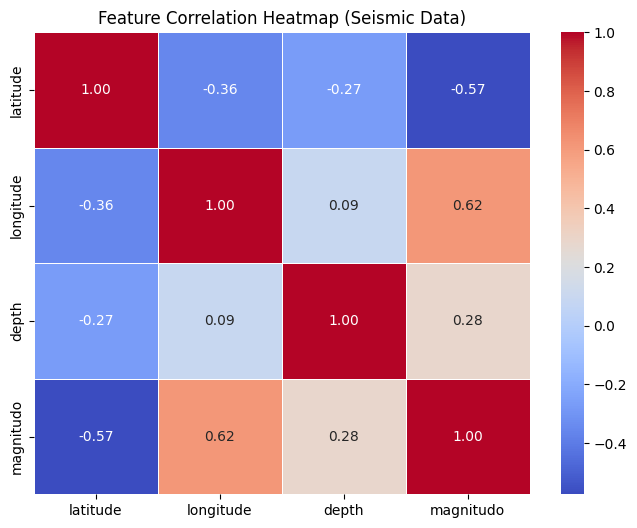

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only required columns
cols = ['latitude', 'longitude', 'depth', 'magnitudo']
data = df[cols]

# Correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Heatmap (Seismic Data)")
plt.show()


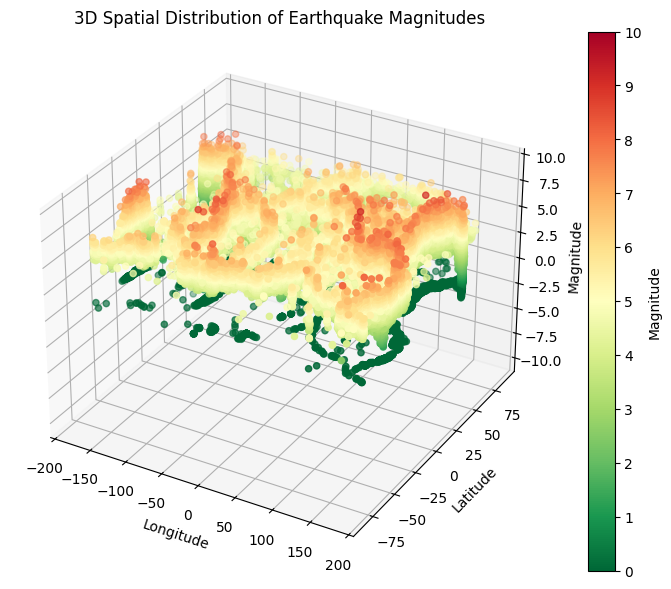

In [ ]:
# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with fixed color scale 0 to 10
scatter = ax.scatter(
    x, y, z,
    c=z,
    cmap='RdYlGn_r',   # green to red
    s=20,
    vmin=0,
    vmax=10
)

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Magnitude")
ax.set_title("3D Spatial Distribution of Earthquake Magnitudes")

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, label="Magnitude")
cbar.set_ticks(range(0, 11))  # 0 to 10 ticks

plt.show()

### GNN Implementation